# 05 · Evaluate the pooled predictors (TwoRoom)

Plans with each pooled model from notebook 04 on the **same 50 start/goal queries and the same CEM
settings** as the reference points of notebook 01, records success rate and time per replan, and draws the
success-versus-time plot.

| point | tokens per frame | from |
|---|---|---|
| LeWM | 1 | notebook 01 on an A100, official checkpoint, 50 episodes |
| DINO-WM full grid | 196 | notebook 01 on an A100, third-party retrain, fp16, 50 episodes |
| `cls`, `mean`, `g2`, `g4`, `g7` | 1, 1, 4, 16, 49 | notebook 04 snapshots, fp32 |

Without a CUDA GPU the notebook runs a tiny smoke configuration on the locally trained 20-episode models.

## 1. Paths and environment variables

In [1]:
import os
import shutil
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path("/content")
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# must be set before importing stable_worldmodel / mujoco
os.environ["STABLEWM_HOME"] = str(ROOT / "stablewm")      # datasets/ and checkpoints/ live here
os.environ.setdefault("WANDB_MODE", "disabled")
if sys.platform == "linux":
    os.environ.setdefault("MUJOCO_GL", "egl")             # headless rendering; macOS uses its default

HOME = Path(os.environ["STABLEWM_HOME"])
(HOME / "datasets").mkdir(parents=True, exist_ok=True)
print("root:", ROOT)
print("STABLEWM_HOME:", HOME)
print(f"free disk: {shutil.disk_usage(HOME).free / 1e9:.0f} GB")

root: /content
STABLEWM_HOME: /content/stablewm
free disk: 207 GB


## 2. Install (Colab only)

In [2]:
PACKAGES = [
    "stable-worldmodel[train,env]==0.1.1",
    "hdf5plugin",
    "mujoco>=3.14,<3.15",
    "transformers>=4.50,<5",
    "datasets>=3",
    "huggingface-hub<1",
]

if IN_COLAB:
    import subprocess

    def pip(*args):
        cmd = [sys.executable, "-m", "uv", "pip", "install", "--system", *args]
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print((result.stdout + result.stderr)[-6000:])      # uv's own error message
            raise RuntimeError("install failed, see the output above")

    # Install system dependency swig required to compile box2d-py
    print("Installing system dependencies (swig)... ")
    subprocess.run(["apt-get", "update", "-y"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(["apt-get", "install", "-y", "swig"], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)

    if sys.version_info >= (3, 13):
        stub = Path("/content/labmaze_stub")
        (stub / "labmaze").mkdir(parents=True, exist_ok=True)
        (stub / "labmaze" / "__init__.py").write_text("# empty stand-in, see notebook section 2\n")
        (stub / "pyproject.toml").write_text(
            "[build-system]\nrequires = [\"setuptools\"]\nbuild-backend = \"setuptools.build_meta\"\n"
            "[project]\nname = \"labmaze\"\nversion = \"1.0.6\"\n"
        )
        pip(str(stub))

    pip(*PACKAGES)
    print("installed on python", sys.version.split()[0])

Installing system dependencies (swig)... 
installed on python 3.13.15


## 3. The `dwt` package

Same as notebook 04: the checkpoints' `config.json` refers to `dwt.models.PooledDino`.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
MODELS_SRC = r'''"""Pooled-token DINO-WM variants, built on stable_worldmodel's PreJEPA.

The frozen encoder is DINOv2 ViT-S/14 fed exactly as the full-grid reference feeds it (frames scaled
to [-1, 1], resized to 196 px, `forward_features`), followed by a fixed pooling of the 14 x 14 patch grid.
Only the token count differs between the variants and the reference:

    cls   1   CLS token
    mean  1   mean over the 196 patches
    g2    4   adaptive average pool to 2 x 2
    g4   16   adaptive average pool to 4 x 4
    g7   49   adaptive average pool to 7 x 7
    full 196  no pooling (the reference layout)

A model is `PreJEPA(encoder=PooledDino(variant), predictor=CausalPredictor(num_patches=k, ...))`, so
planning (`get_cost`), rollout and checkpoint loading (`load_pretrained`) come from stable_worldmodel.
"""
from types import SimpleNamespace

import torch
import torch.nn.functional as F
from torch import nn
from torchvision.transforms import v2 as transforms

from stable_worldmodel.wm.prejepa.module import CausalPredictor, Embedder
from stable_worldmodel.wm.prejepa.prejepa import PreJEPA

GRID = 14                     # 196 px / 14 px patches
FEAT_DIM = 384                # DINOv2 ViT-S
ENCODER_PX = GRID * 14
HUB_NAME = "dinov2_vits14"
TOKENS = {"cls": 1, "mean": 1, "g2": 4, "g4": 16, "g7": 49, "full": GRID * GRID}
_GRID_SIDE = {"g2": 2, "g4": 4, "g7": 7, "full": GRID}


def pixel_transform(img_size=224):
    """uint8 HWC frame -> float CHW in [-1, 1], as the reference's `default_transform`."""
    return transforms.Compose([
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Resize(img_size),
        transforms.CenterCrop(img_size),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])


def pool_tokens(cls_token, patches, variant):
    """cls_token (B, 384), patches (B, 196, 384) -> (B, TOKENS[variant], 384)."""
    if variant == "cls":
        return cls_token[:, None]
    if variant == "mean":
        return patches.mean(1, keepdim=True)
    side = _GRID_SIDE[variant]
    if side == GRID:
        return patches
    grid = patches.transpose(1, 2).reshape(patches.shape[0], FEAT_DIM, GRID, GRID)
    if grid.device.type == "mps":        # MPS cannot pool 14 -> 4 (non-divisible sizes)
        grid = grid.cpu()
    pooled = F.adaptive_avg_pool2d(grid, side).flatten(2).transpose(1, 2)
    return pooled.to(patches.device)


class PooledDino(nn.Module):
    """Frozen DINOv2 -> pooled tokens, returned the way PreJEPA reads HF encoders
    (`.last_hidden_state`, whose first token it drops as the CLS placeholder).

    The backbone is deliberately not registered as a submodule: it is frozen and public, so it stays out of
    `state_dict()` and checkpoints hold only the trained parts. It follows the input tensor's device.
    """

    def __init__(self, variant, hub_name=HUB_NAME):
        super().__init__()
        assert variant in TOKENS, f"unknown variant {variant!r}, expected one of {list(TOKENS)}"
        self.variant = variant
        self.hub_name = hub_name
        backbone = torch.hub.load("facebookresearch/dinov2", hub_name).eval()
        backbone.requires_grad_(False)
        self._backbone = [backbone]
        self.config = SimpleNamespace(hidden_size=FEAT_DIM)       # mirrors the HF attribute PreJEPA users read

    @property
    def backbone(self):
        return self._backbone[0]

    @property
    def num_tokens(self):
        return TOKENS[self.variant]

    @torch.no_grad()
    def forward(self, pixels, **kwargs):
        """pixels (B, 3, H, W) in [-1, 1] -> last_hidden_state (B, 1 + tokens, 384)."""
        backbone = self.backbone
        if next(backbone.parameters()).device != pixels.device:
            backbone.to(pixels.device)
            self._backbone = [backbone]
        x = F.interpolate(pixels, size=(ENCODER_PX, ENCODER_PX), mode="bilinear",
                          antialias=True, align_corners=False)
        out = backbone.forward_features(x)
        tokens = pool_tokens(out["x_norm_clstoken"], out["x_norm_patchtokens"], self.variant)
        return SimpleNamespace(last_hidden_state=torch.cat([out["x_norm_clstoken"][:, None], tokens], dim=1))


def model_config(variant, action_dim=2, frameskip=5, history=3, action_emb=10,
                 depth=6, heads=16, mlp_dim=2048, dim_head=64, dropout=0.1):
    """Hydra-instantiable config of a pooled DINO-WM; the predictor hyperparameters are the reference's."""
    return {
        "_target_": "stable_worldmodel.wm.PreJEPA",
        "history_size": history,
        "num_pred": 1,
        "interpolate_pos_encoding": False,
        "encoder": {"_target_": "dwt.models.PooledDino", "variant": variant},
        "predictor": {
            "_target_": "stable_worldmodel.wm.prejepa.module.CausalPredictor",
            "num_patches": TOKENS[variant], "num_frames": history, "dim": FEAT_DIM + action_emb,
            "depth": depth, "heads": heads, "mlp_dim": mlp_dim, "dim_head": dim_head,
            "dropout": dropout, "emb_dropout": 0.0,
        },
        "extra_encoders": {
            "_target_": "torch.nn.ModuleDict",
            "modules": {"action": {"_target_": "stable_worldmodel.wm.prejepa.module.Embedder",
                                   "in_chans": action_dim * frameskip, "emb_dim": action_emb}},
        },
    }


def build_model(variant, **kwargs):
    """Instantiate a pooled DINO-WM from `model_config` (same code path as `load_pretrained`)."""
    from hydra.utils import instantiate
    return instantiate(model_config(variant, **kwargs))


def trainable_parameters(model):
    """Predictor and action embedder; the encoder is frozen and lives outside the state dict anyway."""
    return [p for n, p in model.named_parameters() if n.startswith(("predictor.", "extra_encoders."))]
'''

INIT_SRC = r'''"""dwt: pooled-token DINO world models (token budget study)."""
'''

SRC_DIR = ROOT / "src"
if IN_COLAB:
    (SRC_DIR / "dwt").mkdir(parents=True, exist_ok=True)
    (SRC_DIR / "dwt" / "__init__.py").write_text(INIT_SRC)
    (SRC_DIR / "dwt" / "models.py").write_text(MODELS_SRC)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import dwt.models

print("dwt.models from", dwt.models.__file__)

dwt.models from /content/src/dwt/models.py


## 4. Imports and settings

In [5]:
import csv
import datetime
import json
import platform
import time
import warnings
from importlib.metadata import version

import numpy as np
import torch
from sklearn import preprocessing

warnings.filterwarnings("ignore")
import stable_worldmodel as swm

from dwt.models import TOKENS, pixel_transform

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else DEVICE
SMOKE = DEVICE != "cuda"

ENV_NAME = "swm/TwoRoom-v1"
TAG = "tworoom_local_ep20" if SMOKE else "tworoom_ep2000"     # checkpoint family from notebook 04
STEP = 30 if SMOKE else 30000                                  # which milestone snapshot to evaluate
VARIANTS = ["cls", "mean", "g2", "g4", "g7"]
SEED = 42
N_EVAL = 2 if SMOKE else 50
GOAL_OFFSET, EVAL_BUDGET = 25, 50
PLAN = dict(horizon=5, receding_horizon=5, action_block=5)
CEM = dict(num_samples=16, n_steps=2, topk=4) if SMOKE else dict(num_samples=300, n_steps=30, topk=30)

RESULTS_DIR = ROOT / "results"
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)
CKPT_DIR = HOME / "checkpoints"
DRIVE_DIR = Path("/content/drive/MyDrive/dino-wm-tokens") if IN_COLAB else None

print("python", platform.python_version(), "| torch", torch.__version__, "| device", GPU)
print("smoke configuration" if SMOKE else "full configuration", "|", N_EVAL, "episodes | CEM", CEM, "| snapshots at step", STEP)

python 3.13.15 | torch 2.11.0+cu130 | device NVIDIA A100-SXM4-40GB
full configuration | 50 episodes | CEM {'num_samples': 300, 'n_steps': 30, 'topk': 30} | snapshots at step 30000


## 5. Dataset and the pinned queries

The dataset provides the start states and goal images. The 50 queries are the ones notebook 01 drew (embedded here) and are checked against a fresh draw.

In [6]:
import tarfile
import urllib.request

import zstandard
from tqdm.auto import tqdm

TWOROOM_URL = "https://huggingface.co/datasets/quentinll/lewm-tworooms/resolve/main/tworoom.tar.zst"
MIN_FREE_GB = 20
LOCAL_EPISODES = 20


def download_and_extract(url, dest_dir):
    """Stream a .tar.zst from `url` and extract it into `dest_dir`."""
    with urllib.request.urlopen(url) as resp:
        total = int(resp.headers.get("Content-Length", 0)) or None
        with tqdm.wrapattr(resp, "read", total=total, desc=Path(url).name) as raw:
            with zstandard.ZstdDecompressor().stream_reader(raw) as zr:
                with tarfile.open(fileobj=zr, mode="r|") as tar:
                    tar.extractall(dest_dir)


def collect_local_tworoom(path, episodes):
    from stable_worldmodel.envs.two_room import ExpertPolicy

    world = swm.World("swm/TwoRoom-v1", num_envs=4, image_shape=(224, 224),
                      max_episode_steps=100, render_mode="rgb_array")
    world.set_policy(ExpertPolicy(action_noise=2.0, action_repeat_prob=0.05))
    world.collect(path, episodes=episodes, seed=0, format="hdf5")
    world.close()


free_gb = shutil.disk_usage(HOME).free / 1e9
if (HOME / "datasets" / "tworoom.h5").exists():
    DATASET = "tworoom"
elif free_gb >= MIN_FREE_GB:
    download_and_extract(TWOROOM_URL, HOME / "datasets")
    DATASET = "tworoom"
else:
    DATASET = "tworoom_local"
    if not (HOME / "datasets" / "tworoom_local.h5").exists():
        print(f"only {free_gb:.0f} GB free: collecting {LOCAL_EPISODES} local episodes instead")
        collect_local_tworoom(HOME / "datasets" / "tworoom_local.h5", LOCAL_EPISODES)

dataset = swm.data.HDF5Dataset(DATASET, keys_to_cache=["action", "proprio"])
lengths, offsets = np.asarray(dataset.lengths), np.asarray(dataset.offsets)
print(f"dataset: {DATASET} | {len(lengths)} episodes | {lengths.sum()} steps | columns: {dataset.column_names}")

tworoom.tar.zst:   0%|          | 0/3425937909 [00:00<?, ?it/s]

dataset: tworoom | 10000 episodes | 920809 steps | columns: ['action', 'distance_to_target', 'ep_idx', 'id', 'observation', 'pixels', 'pos_agent', 'pos_target', 'proprio', 'render_time', 'reward', 'step_idx', 'terminated', 'truncated']


In [7]:
PINNED = {"dataset": "tworoom", "seed": 42, "goal_offset": 25, "episodes": [644, 687, 872, 905, 933, 953, 1287, 1661, 1832, 2019, 2280, 2773, 3558, 3719, 4032, 4339, 4398, 4445, 4467, 4515, 4516, 5014, 5141, 5272, 5459, 5552, 6320, 6446, 6552, 6791, 6988, 7021, 7189, 7370, 7597, 7627, 7751, 7797, 7826, 7873, 8241, 8289, 8411, 8598, 8601, 8895, 8949, 9277, 9711, 9757], "start_steps": [42, 68, 25, 16, 20, 17, 72, 21, 10, 36, 50, 13, 57, 39, 0, 7, 52, 6, 38, 21, 0, 72, 7, 33, 55, 36, 28, 26, 41, 37, 59, 44, 16, 22, 55, 48, 27, 32, 66, 32, 30, 18, 21, 31, 39, 31, 49, 75, 8, 70]}

row_episode = np.repeat(np.arange(len(lengths)), lengths)
row_step = np.arange(lengths.sum()) - np.repeat(offsets, lengths)
valid_rows = np.nonzero(row_step <= np.repeat(lengths, lengths) - GOAL_OFFSET - 1)[0]
rng = np.random.default_rng(SEED)
rows = np.sort(valid_rows[rng.choice(len(valid_rows) - 1, size=min(50, len(valid_rows) - 1), replace=False)])
QUERIES = {"episodes": row_episode[rows].tolist(), "start_steps": row_step[rows].tolist()}
if DATASET == PINNED["dataset"]:
    assert QUERIES == {k: PINNED[k] for k in QUERIES}, "queries differ from the pinned ones"
    print("queries match the pinned file (seed", SEED, ")")
else:
    print("smoke dataset: queries drawn fresh")

queries match the pinned file (seed 42 )


## 6. Load the pooled models

Each snapshot folder (`weights.pt` + `config.json` + `meta.json`) is restored from Drive if needed and
rebuilt with `load_pretrained`. Actions are scaled with the exact statistics the model was trained with
(from `meta.json`), so training and planning see the same action space.

In [8]:
def restore(name):
    if DRIVE_DIR is not None and not (CKPT_DIR / name).exists():
        shutil.copytree(DRIVE_DIR / "checkpoints" / name, CKPT_DIR / name)


def action_scaler(mean, std):
    s = preprocessing.StandardScaler()
    s.mean_, s.scale_, s.var_ = np.asarray(mean), np.asarray(std), np.asarray(std) ** 2
    s.n_features_in_ = len(mean)
    return s


MODELS = {}
for variant in VARIANTS:
    name = f"dwt_{TAG}_{variant}_step{STEP}"
    restore(name)
    model = swm.wm.utils.load_pretrained(name).to(DEVICE).eval()
    model.requires_grad_(False)
    meta = json.loads((CKPT_DIR / name / "meta.json").read_text())
    MODELS[f"pooled_{variant}"] = dict(
        model=model, transform=pixel_transform(), tokens_per_frame=TOKENS[variant], feat_dim=384,
        encoder="dinov2_vits14 (frozen)", pooling=variant, precision="fp32", n_eval=N_EVAL,
        train_episodes=meta["train_episodes"], steps=meta["steps_done"], val_mse=meta["val_mse"],
        process={"action": action_scaler(meta["action_mean"], meta["action_std"])},
    )
    print(f"{variant:5s} {TOKENS[variant]:3d} tokens | step {meta['steps_done']} | val MSE {meta['val_mse']:.4f}")

2026-10-06 12:28:01.547 | INFO     | stable_worldmodel.wm.utils:_resolve_folder:137 - Loading checkpoint from folder /content/stablewm/checkpoints/dwt_tworoom_ep2000_cls_step30000...


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 396MB/s]


cls     1 tokens | step 30000 | val MSE 0.0047


2026-10-06 12:28:11.370 | INFO     | stable_worldmodel.wm.utils:_resolve_folder:137 - Loading checkpoint from folder /content/stablewm/checkpoints/dwt_tworoom_ep2000_mean_step30000...
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


...

g2      4 tokens | step 30000 | val MSE 0.0030


2026-10-06 12:28:27.408 | INFO     | stable_worldmodel.wm.utils:_resolve_folder:137 - Loading checkpoint from folder /content/stablewm/checkpoints/dwt_tworoom_ep2000_g4_step30000...
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


g4     16 tokens | step 30000 | val MSE 0.0036


2026-10-06 12:28:32.276 | INFO     | stable_worldmodel.wm.utils:_resolve_folder:137 - Loading checkpoint from folder /content/stablewm/checkpoints/dwt_tworoom_ep2000_g7_step30000...
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


g7     49 tokens | step 30000 | val MSE 0.0051


## 7. Evaluation function

Identical to notebook 01: pinned queries through `World.evaluate`, every solver call timed, time per replan = solver time / environments planned.

In [9]:
CALLABLES = [
    {"method": "_set_state", "args": {"state": {"value": "proprio"}}},
    {"method": "_set_goal_state", "args": {"goal_state": {"value": "goal_proprio"}}},
]


def sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


def run_eval(name, n_eval, video=True):
    spec = MODELS[name]
    solver = swm.solver.CEMSolver(model=spec["model"], device=DEVICE, seed=SEED, **CEM)
    solve_log = []
    plain_solve = solver.solve

    def timed_solve(info_dict, init_action=None):
        n_envs = len(next(iter(info_dict.values())))
        sync(); t0 = time.perf_counter()
        out = plain_solve(info_dict, init_action=init_action)
        sync(); solve_log.append((n_envs, time.perf_counter() - t0))
        return out

    solver.solve = timed_solve
    world = swm.World(ENV_NAME, num_envs=n_eval, image_shape=(224, 224), max_episode_steps=2 * EVAL_BUDGET)
    world.set_policy(swm.policy.WorldModelPolicy(
        solver=solver, config=swm.PlanConfig(**PLAN), process=spec["process"],
        transform={"pixels": spec["transform"], "goal": spec["transform"]},
    ))
    t0 = time.perf_counter()
    metrics = world.evaluate(
        dataset=dataset, episodes_idx=QUERIES["episodes"][:n_eval], start_steps=QUERIES["start_steps"][:n_eval],
        goal_offset=GOAL_OFFSET, eval_budget=EVAL_BUDGET, callables=CALLABLES,
        video=(HOME / "videos" / name) if video else None,
    )
    wall = time.perf_counter() - t0
    world.close()
    per_replan = [s / n for n, s in solve_log]
    return {
        "method": name, "n_episodes": n_eval, "success_rate": metrics["success_rate"],
        "episode_successes": np.asarray(metrics["episode_successes"]).astype(int).tolist(),
        "replans": int(sum(n for n, _ in solve_log)),
        "time_per_replan_mean_s": float(sum(s for _, s in solve_log) / sum(n for n, _ in solve_log)),
        "time_per_replan_median_s": float(np.median(per_replan)), "wall_time_s": wall,
    }

## 8. Run all variants

Each result is appended to `results/runs.csv` as soon as it is finished. The biggest variant (`g7`) is expected to take the longest; all should be far below the full grid's 252 s per replan.

In [10]:
FIELDS = ["run_id", "date", "git_commit", "swm_version", "gpu", "env", "method", "encoder", "layer", "pooling",
          "tokens_per_frame", "feat_dim", "train_episodes", "cem_samples", "cem_iters", "horizon",
          "precision", "compiled", "seed", "n_episodes", "success_rate", "time_per_replan_median_s",
          "time_encode_s", "time_predictor_s", "time_cem_other_s", "notes"]
RUNS_CSV = RESULTS_DIR / ("runs_smoke.csv" if SMOKE else "runs.csv")


def log_run(result):
    spec = MODELS[result["method"]]
    row = dict.fromkeys(FIELDS, "")
    row.update(
        run_id=f"{result['method']}_tworoom_seed{SEED}_{datetime.datetime.now():%Y%m%d-%H%M%S}",
        date=f"{datetime.date.today()}", swm_version=version("stable-worldmodel"), gpu=GPU, env="tworoom",
        method=result["method"], encoder=spec["encoder"], layer="last", pooling=spec["pooling"],
        tokens_per_frame=spec["tokens_per_frame"], feat_dim=spec["feat_dim"], train_episodes=spec["train_episodes"],
        cem_samples=CEM["num_samples"], cem_iters=CEM["n_steps"], horizon=PLAN["horizon"],
        precision=spec["precision"], compiled=False, seed=SEED, n_episodes=result["n_episodes"],
        success_rate=result["success_rate"], time_per_replan_median_s=round(result["time_per_replan_median_s"], 3),
        notes=f"dataset={DATASET}; checkpoint={TAG}_step{spec['steps']}; val_mse={spec['val_mse']:.4f}; "
              f"mean_replan_s={result['time_per_replan_mean_s']:.3f}; wall_s={result['wall_time_s']:.0f}; replans={result['replans']}",
    )
    new_file = not RUNS_CSV.exists()
    with RUNS_CSV.open("a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDS)
        if new_file:
            writer.writeheader()
        writer.writerow(row)


RESULTS = {}
for name in MODELS:
    RESULTS[name] = run_eval(name, n_eval=MODELS[name]["n_eval"])
    log_run(RESULTS[name])
    r = RESULTS[name]
    print(f"\n{name}: success {r['success_rate']:.0f}% | {r['time_per_replan_median_s']:.2f} s per replan (median) "
          f"| wall {r['wall_time_s'] / 60:.1f} min\n")

CEM solve time: 37.0287 seconds
CEM solve time: 4.1868 seconds

pooled_cls: success 92% | 0.72 s per replan (median) | wall 1.0 min

CEM solve time: 34.7647 seconds
CEM solve time: 3.5187 seconds

pooled_mean: success 96% | 0.70 s per replan (median) | wall 1.0 min

CEM solve time: 76.6089 seconds
CEM solve time: 4.6176 seconds

pooled_g2: success 100% | 1.54 s per replan (median) | wall 1.7 min

CEM solve time: 240.6075 seconds

pooled_g4: success 100% | 4.81 s per replan (median) | wall 4.2 min

CEM solve time: 745.3207 seconds

pooled_g7: success 100% | 14.91 s per replan (median) | wall 12.7 min



## 9. Table and the success-versus-time plot

The two reference points come from notebook 01 (`results/runs.csv`).

,tokens,precision,episodes,success,s_per_replan
method,,,,,
lewm,1,fp32,50,86.0,0.711000
dinowm_noprop,196,fp16,50,100.0,44.981000
pooled_cls,1,fp32,50,92.0,0.719237
pooled_mean,1,fp32,50,96.0,0.699568
pooled_g2,4,fp32,50,100.0,1.535774
pooled_g4,16,fp32,50,100.0,4.812166
pooled_g7,49,fp32,50,100.0,14.906428


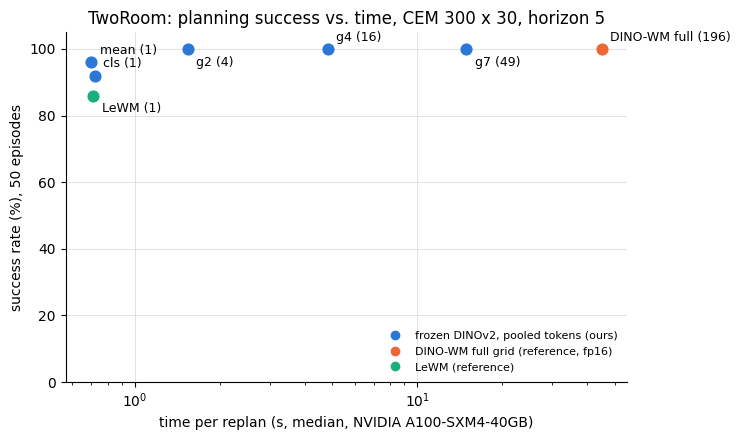

rows appended to /content/results/runs.csv


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

REFERENCE = [
 {
  "method": "lewm",
  "tokens_per_frame": 1,
  "precision": "fp32",
  "n_episodes": 50,
  "success_rate": 86.0,
  "time_per_replan_median_s": 0.711,
  "gpu": "NVIDIA A100-SXM4-40GB"
 },
 {
  "method": "dinowm_noprop",
  "tokens_per_frame": 196,
  "precision": "fp16",
  "n_episodes": 50,
  "success_rate": 100.0,
  "time_per_replan_median_s": 44.981,
  "gpu": "NVIDIA A100-SXM4-40GB"
 }
]

assert SMOKE or GPU == REFERENCE[0]["gpu"], f"references were timed on {REFERENCE[0]['gpu']}, this run is on {GPU}: timings not comparable"
rows = [dict(method=r["method"], tokens=r["tokens_per_frame"], precision=r["precision"], episodes=r["n_episodes"],
             success=r["success_rate"], s_per_replan=r["time_per_replan_median_s"]) for r in REFERENCE]
rows += [dict(method=name, tokens=MODELS[name]["tokens_per_frame"], precision="fp32", episodes=r["n_episodes"],
              success=r["success_rate"], s_per_replan=r["time_per_replan_median_s"]) for name, r in RESULTS.items()]
table = pd.DataFrame(rows).set_index("method")
display(table)

COLORS = {"pooled": "#2a78d6", "dinowm_noprop": "#eb6834", "lewm": "#1baf7a"}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for i, (method, row) in enumerate(table.sort_values("s_per_replan").iterrows()):
    family = "pooled" if method.startswith("pooled_") else method
    label = {"pooled": f"{method[7:]} ({row.tokens})", "dinowm_noprop": "DINO-WM full (196)", "lewm": "LeWM (1)"}[family]
    ax.scatter(row.s_per_replan, row.success, s=60, color=COLORS[family], zorder=3)
    ax.annotate(label, (row.s_per_replan, row.success), xytext=(6, 6 if i % 2 == 0 else -12),   # alternate to limit overlaps
                textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel(f"time per replan (s, median, {GPU})")
ax.set_ylabel(f"success rate (%), {N_EVAL} episodes")
ax.set_ylim(0, 105)
ax.set_title("TwoRoom: planning success vs. time, CEM 300 x 30, horizon 5")
ax.grid(True, which="major", color="#dddddd", linewidth=0.6, zorder=0)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=l) for l, c in
           [("frozen DINOv2, pooled tokens (ours)", COLORS["pooled"]), ("DINO-WM full grid (reference, fp16)", COLORS["dinowm_noprop"]),
            ("LeWM (reference)", COLORS["lewm"])]]
ax.legend(handles=handles, loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / ("pareto_tworoom_smoke.png" if SMOKE else "pareto_tworoom.png"), dpi=150)
plt.show()
print("rows appended to", RUNS_CSV)

## Notes for reading the numbers

- One seed, 50 episodes per model, all timed on the same GPU.
- The pooled models were trained on 2,000 episodes for 30,000 steps; the references on all 10,000 episodes
  for far longer. Their absolute success is therefore a lower bound on what the token budget allows.
- Precision: pooled models and LeWM in fp32, DINO-WM in fp16 (fp32 was 2.4x slower, 613 s per replan).
- On Colab, download `results/runs.csv` and `results/figures/pareto_tworoom.png` before the session ends.